# Phân tích rủi ro bảo hiểm xe cơ giới và định giá gói bảo hiểm dựa trên hồ sơ lái xe

Notebook này được tái cấu trúc theo pipeline **Train → Validation → Test**, trong đó tập Test chỉ được dùng ở bước đánh giá cuối cùng. Bài toán được tách thành:

1. **Risk modeling:** dự đoán xác suất khách hàng có ít nhất một yêu cầu bồi thường (`IsClaim`).
2. **Pricing modeling:** dự đoán `PurePremium = ClaimAmount / Exposure` bằng Tweedie, Random Forest và CatBoost.

Các điểm sửa quan trọng: tránh data leakage ở calibration/threshold/Optuna; CatBoost xử lý categorical trực tiếp; bổ sung PR-AUC/Brier/Gini; benchmark phí phẳng được ước lượng từ Train; không cap `ClaimAmount` trên toàn bộ dữ liệu trước khi chia tập.

In [1]:
# Nếu môi trường chưa có các thư viện cần thiết, bỏ comment dòng dưới và chạy một lần.
%pip install -q catboost optuna shap imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    mean_tweedie_deviance, mean_absolute_error, mean_squared_error
)
from sklearn.base import clone
from catboost import CatBoostClassifier, CatBoostRegressor
import optuna
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Thư viện đã được nạp.")

Note: you may need to restart the kernel to use updated packages.
Thư viện đã được nạp.


## 1. Tải và kiểm tra dữ liệu

In [2]:
print("--- Đang tải dữ liệu Frequency và Severity từ OpenML ---")
df_freq = fetch_openml(data_id=41214, as_frame=True, parser="auto").frame
df_sev = fetch_openml(data_id=41215, as_frame=True, parser="auto").frame

# IDpol dùng để nối chính xác giữa frequency và severity.
df_freq["IDpol"] = df_freq["IDpol"].astype(int)
df_sev["IDpol"] = df_sev["IDpol"].astype(int)

sev_agg = df_sev.groupby("IDpol", as_index=False)["ClaimAmount"].sum()
sev_agg = sev_agg.rename(columns={"ClaimAmount": "ClaimAmount"})

df = df_freq.merge(sev_agg, on="IDpol", how="left")
df["ClaimAmount"] = df["ClaimAmount"].fillna(0.0)

print(f"Số hợp đồng: {len(df):,}")
print(f"Số cột: {df.shape[1]}")
print(f"Số hợp đồng có claim: {(df['ClaimNb'] > 0).sum():,}")
print(f"Tỷ lệ không claim: {(df['ClaimNb'] == 0).mean()*100:.2f}%")
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(15))
print("\n5 dòng đầu:")
print(df.head())

--- Đang tải dữ liệu Frequency và Severity từ OpenML ---
Số hợp đồng: 678,013
Số cột: 13
Số hợp đồng có claim: 34,060
Tỷ lệ không claim: 94.98%

Missing values:
IDpol          0
ClaimNb        0
Exposure       0
Area           0
VehPower       0
VehAge         0
DrivAge        0
BonusMalus     0
VehBrand       0
VehGas         0
Density        0
Region         0
ClaimAmount    0
dtype: int64

5 dòng đầu:
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0      1        1      0.10    D         5       0       55          50   
1      3        1      0.77    D         5       0       55          50   
2      5        1      0.75    B         6       2       52          50   
3     10        1      0.09    B         7       0       46          50   
4     11        1      0.84    B         7       0       46          50   

  VehBrand     VehGas  Density Region  ClaimAmount  
0      B12  'Regular'     1217    R82          0.0  
1      B12  'Regular'     1217    R

## 2. Làm sạch và tạo biến

Lưu ý: `ClaimAmount` được giữ nguyên làm target pricing chính. Nếu cần sensitivity analysis với winsorization, thực hiện sau khi chia Train/Validation/Test và chỉ ước lượng ngưỡng từ Train.

In [3]:
# Giữ Exposure > 0 vì đây là thời lượng bảo hiểm dùng làm exposure.
df = df.loc[df["Exposure"] > 0].copy()

# Không clip Exposure về 1 năm: Exposure là thời lượng quan sát thực tế.
# Chỉ tạo một biến cap để sensitivity analysis, không dùng làm target chính.
claim_cap_train_placeholder = np.nan

df["IsClaim"] = (df["ClaimNb"] > 0).astype(int)
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]
df["Frequency"] = df["ClaimNb"] / df["Exposure"]

df["Is_Young_Driver"] = (df["DrivAge"] < 25).astype(int)
df["High_BonusMalus"] = (df["BonusMalus"] > 100).astype(int)
df["LogDensity"] = np.log1p(df["Density"])

num_features = [
    "VehPower", "VehAge", "DrivAge", "BonusMalus", "LogDensity",
    "Is_Young_Driver", "High_BonusMalus"
]
cat_features = ["Area", "VehBrand", "VehGas", "Region"]
feature_cols = num_features + cat_features

# Ép categorical về string cho CatBoost native categorical features.
for c in cat_features:
    df[c] = df[c].astype(str)

# Chỉ giữ các hàng có target và predictor hợp lệ.
needed = feature_cols + ["IsClaim", "PurePremium", "ClaimAmount", "ClaimNb", "Exposure", "IDpol"]
df = df.dropna(subset=needed).copy()

print("Kích thước sau làm sạch:", df.shape)
print("Exposure min/max:", df["Exposure"].min(), df["Exposure"].max())
print("PurePremium min/max:", df["PurePremium"].min(), df["PurePremium"].max())
print("Claim amount > 0:", (df["ClaimAmount"] > 0).mean()*100, "%")

Kích thước sau làm sạch: (678013, 19)
Exposure min/max: 0.0027322404371584 2.01
PurePremium min/max: 0.0 18524548.0
Claim amount > 0: 3.67898550617761 %


## 3. EDA: phân phối claim và tương tác rủi ro

         Age_Group      Risk_History  Total_Exposure  Total_Claims  Observed_Frequency_%
         Trẻ (<25) BonusMalus <= 100    14966.464416          2323             15.521368
         Trẻ (<25)  BonusMalus > 100     1261.438846           518             41.064218
Trung niên (25-50) BonusMalus <= 100   199419.899415         19150              9.602853
Trung niên (25-50)  BonusMalus > 100     1835.943619           630             34.314779
    Lớn tuổi (>50) BonusMalus <= 100   140541.762629         13287              9.454129
    Lớn tuổi (>50)  BonusMalus > 100      473.936538           194             40.933751


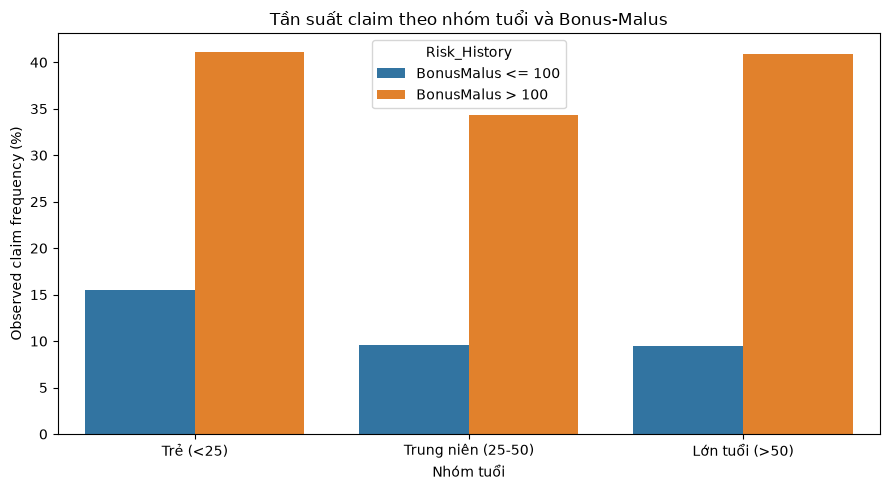

In [4]:
df_analysis = df.copy()
df_analysis["Age_Group"] = pd.cut(
    df_analysis["DrivAge"],
    bins=[0, 25, 50, 100],
    labels=["Trẻ (<25)", "Trung niên (25-50)", "Lớn tuổi (>50)"],
    include_lowest=True
)
df_analysis["Risk_History"] = np.where(
    df_analysis["BonusMalus"] > 100,
    "BonusMalus > 100",
    "BonusMalus <= 100"
)

interaction_matrix = (
    df_analysis.groupby(["Age_Group", "Risk_History"], observed=False)
    .agg(
        Total_Exposure=("Exposure", "sum"),
        Total_Claims=("ClaimNb", "sum")
    )
    .reset_index()
)
interaction_matrix["Observed_Frequency_%"] = (
    interaction_matrix["Total_Claims"] /
    interaction_matrix["Total_Exposure"] * 100
)

print(interaction_matrix.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=interaction_matrix,
    x="Age_Group", y="Observed_Frequency_%", hue="Risk_History", ax=ax
)
ax.set_title("Tần suất claim theo nhóm tuổi và Bonus-Malus")
ax.set_ylabel("Observed claim frequency (%)")
ax.set_xlabel("Nhóm tuổi")
plt.tight_layout()
plt.show()

# EDA Mở rộng

In [5]:
# =========================================================
# EDA MỞ RỘNG
# =========================================================

# Thiết lập hiển thị
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

print("=" * 100)
print("EDA MỞ RỘNG - PHÂN TÍCH RỦI RO BẢO HIỂM XE CƠ GIỚI")
print("=" * 100)

EDA MỞ RỘNG - PHÂN TÍCH RỦI RO BẢO HIỂM XE CƠ GIỚI


In [6]:
# =========================================================
# 1. THỐNG KÊ MÔ TẢ
# =========================================================

numeric_eda = [
    "DrivAge",
    "VehPower",
    "VehAge",
    "BonusMalus",
    "Density",
    "Exposure",
    "ClaimNb",
    "ClaimAmount",
    "Frequency",
    "PurePremium"
]

print("\n" + "=" * 100)
print("1. THỐNG KÊ MÔ TẢ")
print("=" * 100)

display(
    df[numeric_eda]
    .describe()
    .T
    .round(4)
)


1. THỐNG KÊ MÔ TẢ


,count,mean,std,min,25%,50%,75%,max
DrivAge,678013.0000,45.4991,14.1374,18.0000,34.0000,44.0000,55.0000,100.0000
VehPower,678013.0000,6.4546,2.0509,4.0000,5.0000,6.0000,7.0000,15.0000
VehAge,678013.0000,7.0443,5.6662,0.0000,2.0000,6.0000,11.0000,100.0000
BonusMalus,678013.0000,59.7615,15.6367,50.0000,50.0000,50.0000,64.0000,230.0000
Density,678013.0000,1792.4224,3958.6466,1.0000,92.0000,393.0000,1658.0000,27000.0000
Exposure,678013.0000,0.5288,0.3644,0.0027,0.1800,0.4900,0.9900,2.0100
ClaimNb,678013.0000,0.0532,0.2401,0.0000,0.0000,0.0000,0.0000,16.0000
ClaimAmount,678013.0000,88.3600,5822.4543,0.0000,0.0000,0.0000,0.0000,4075400.5600
Frequency,678013.0000,0.2640,4.5939,0.0000,0.0000,0.0000,0.0000,732.0000
PurePremium,678013.0000,383.2608,36820.7041,0.0000,0.0000,0.0000,0.0000,18524548.0000



2. PHÂN PHỐI CLAIM
Tổng số hợp đồng: 678,013
Số hợp đồng có claim: 34,060
Tỷ lệ có claim: 5.02%
Tỷ lệ không claim: 94.98%


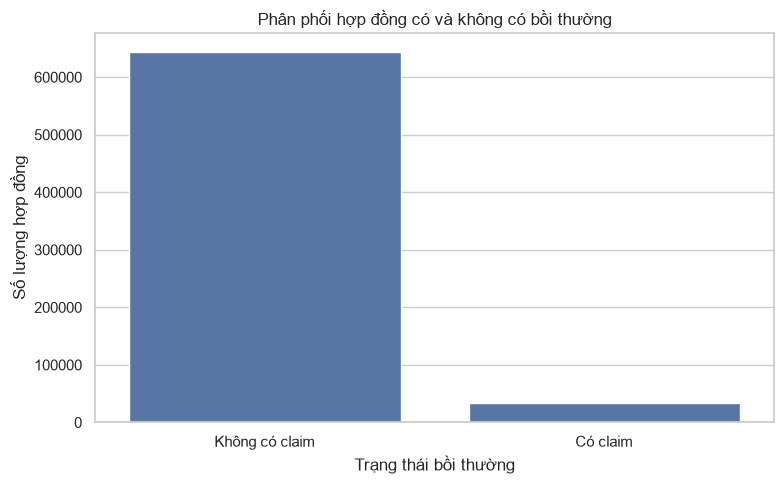

In [7]:
# =========================================================
# 2. PHÂN PHỐI CLAIM / NON-CLAIM
# =========================================================

claim_count = df["IsClaim"].value_counts()

claim_rate = df["IsClaim"].mean()

print("\n" + "=" * 100)
print("2. PHÂN PHỐI CLAIM")
print("=" * 100)

print(f"Tổng số hợp đồng: {len(df):,}")
print(f"Số hợp đồng có claim: {df['IsClaim'].sum():,}")
print(f"Tỷ lệ có claim: {claim_rate:.2%}")
print(f"Tỷ lệ không claim: {1 - claim_rate:.2%}")

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="IsClaim"
)

plt.title("Phân phối hợp đồng có và không có bồi thường")
plt.xlabel("Trạng thái bồi thường")
plt.ylabel("Số lượng hợp đồng")

ax.set_xticklabels(
    ["Không có claim", "Có claim"]
)

plt.tight_layout()
plt.show()


--- Phân tích theo nhóm tuổi ---


,Age_Group,Policies,Exposure,Claims,ClaimAmount,Frequency,Pure_Premium,Claim_Rate
0,<25,38895,16227.9033,2841,12307261.5400,0.1751,758.4012,0.0674
1,25-30,65594,29180.2338,3093,4870387.5400,0.1060,166.9071,0.0444
2,31-40,170097,83937.2990,7522,12433745.4900,0.0896,148.1314,0.0420
3,41-50,165185,88138.3102,9165,11632817.8500,0.1040,131.9837,0.0526
4,51-60,135014,75727.6360,7292,9748765.5000,0.0963,128.7346,0.0507
5,>60,103228,65288.0632,6189,8916238.5800,0.0948,136.5677,0.0565


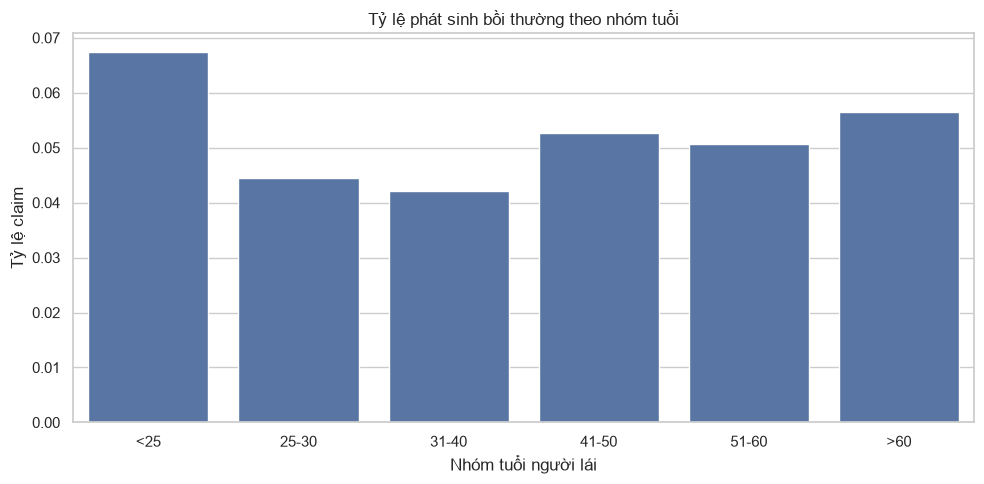

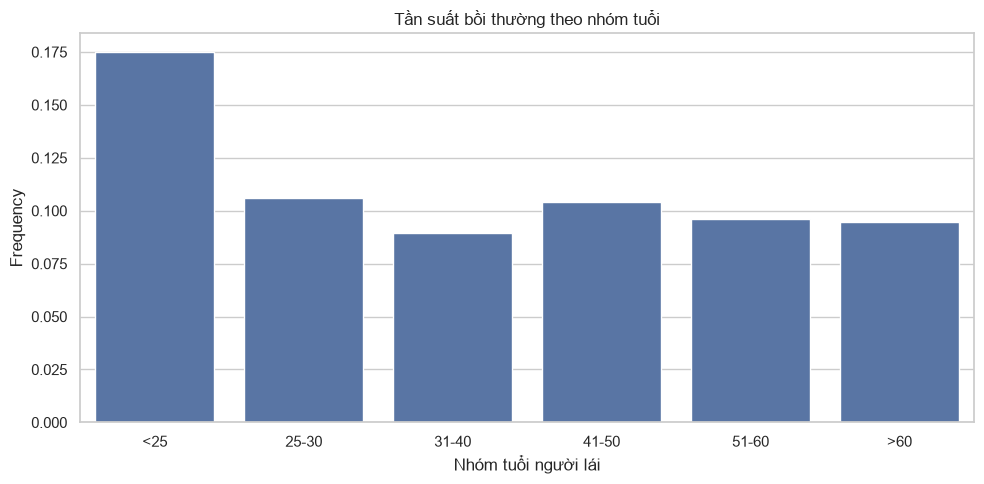

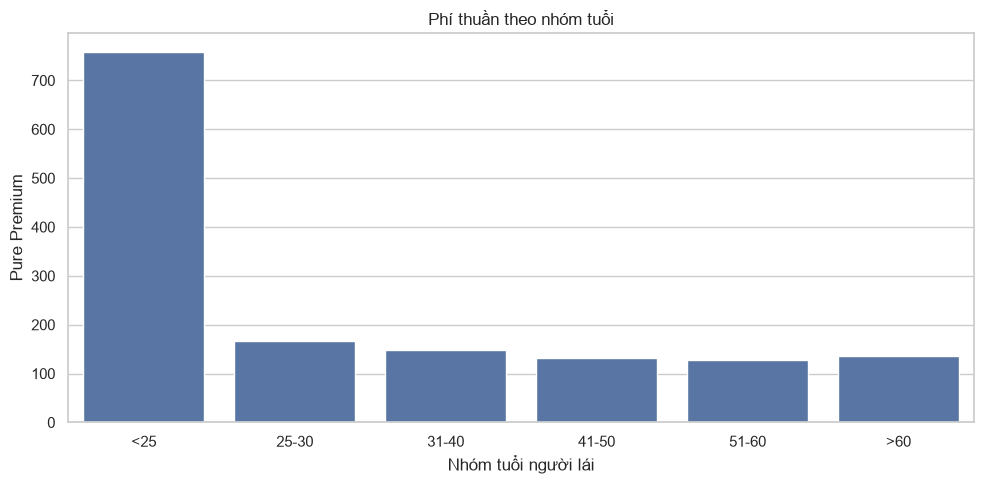

In [8]:
# =========================================================
# 3. PHÂN TÍCH TUỔI NGƯỜI LÁI
# =========================================================

df_age = df.copy()

df_age["Age_Group"] = pd.cut(
    df_age["DrivAge"],
    bins=[0, 25, 30, 40, 50, 60, 100],
    labels=[
        "<25",
        "25-30",
        "31-40",
        "41-50",
        "51-60",
        ">60"
    ],
    include_lowest=True
)
age_analysis = (
    df_age
    .groupby("Age_Group", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

# Claim Rate
age_claim_rate = (
    df_age
    .groupby("Age_Group", observed=False)["IsClaim"]
    .mean()
    .reset_index(name="Claim_Rate")
)

# Frequency
age_analysis["Frequency"] = (
    age_analysis["Claims"] /
    age_analysis["Exposure"]
)

# Pure Premium
age_analysis["Pure_Premium"] = (
    age_analysis["ClaimAmount"] /
    age_analysis["Exposure"]
)

# Ghép Claim Rate
age_analysis = age_analysis.merge(
    age_claim_rate,
    on="Age_Group"
)

print("\n--- Phân tích theo nhóm tuổi ---")
display(
    age_analysis.round(4)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_analysis,
    x="Age_Group",
    y="Claim_Rate"
)

plt.title("Tỷ lệ phát sinh bồi thường theo nhóm tuổi")
plt.xlabel("Nhóm tuổi người lái")
plt.ylabel("Tỷ lệ claim")

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_analysis,
    x="Age_Group",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo nhóm tuổi")
plt.xlabel("Nhóm tuổi người lái")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=age_analysis,
    x="Age_Group",
    y="Pure_Premium"
)

plt.title("Phí thuần theo nhóm tuổi")
plt.xlabel("Nhóm tuổi người lái")
plt.ylabel("Pure Premium")

plt.tight_layout()
plt.show()


--- Phân tích theo công suất xe ---


,Power_Group,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,≤50,678013,358499.4455,36102,59909216.5000,0.0502,0.1007,167.1110
1,51-75,0,0.0000,0,0.0000,NaN,NaN,NaN
2,76-100,0,0.0000,0,0.0000,NaN,NaN,NaN
3,101-150,0,0.0000,0,0.0000,NaN,NaN,NaN
4,>150,0,0.0000,0,0.0000,NaN,NaN,NaN


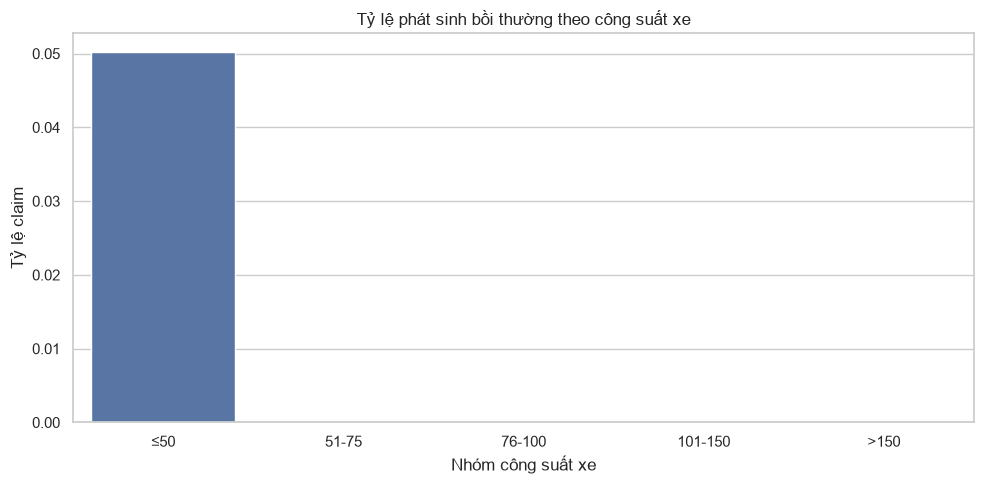

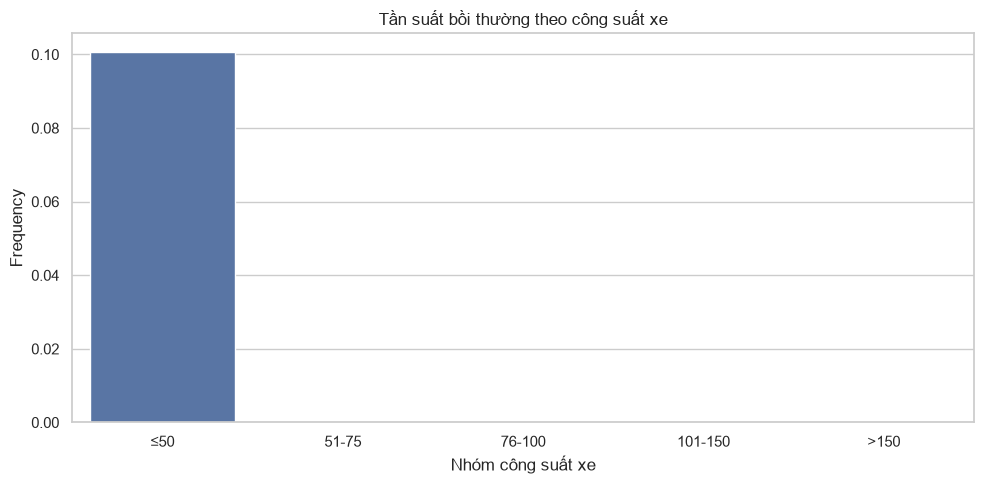

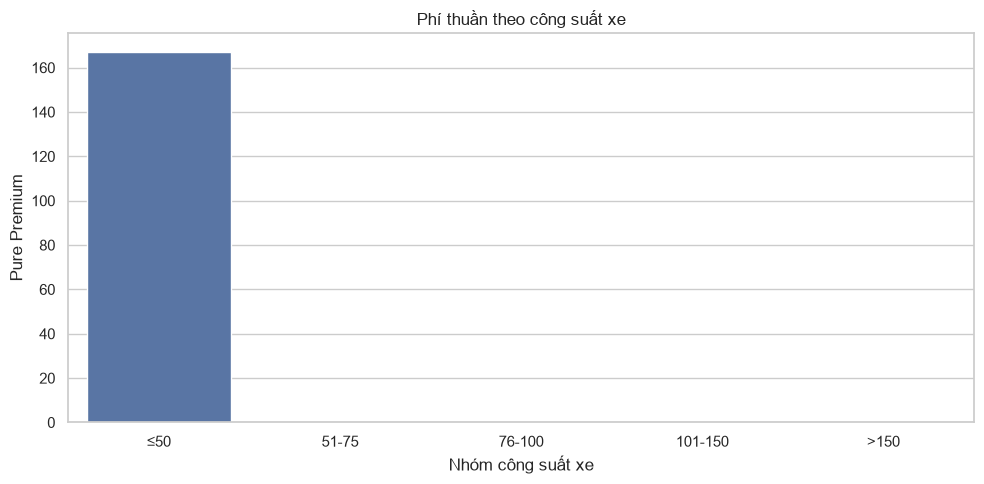

In [9]:
# =========================================================
# 4. PHÂN TÍCH CÔNG SUẤT XE
# =========================================================

df_power = df.copy()

df_power["Power_Group"] = pd.cut(
    df_power["VehPower"],
    bins=[0, 50, 75, 100, 150, np.inf],
    labels=[
        "≤50",
        "51-75",
        "76-100",
        "101-150",
        ">150"
    ],
    include_lowest=True
)
power_analysis = (
    df_power
    .groupby("Power_Group", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

power_analysis["Claim_Rate"] = (
    df_power
    .groupby("Power_Group", observed=False)["IsClaim"]
    .mean()
    .values
)

power_analysis["Frequency"] = (
    power_analysis["Claims"] /
    power_analysis["Exposure"]
)

power_analysis["Pure_Premium"] = (
    power_analysis["ClaimAmount"] /
    power_analysis["Exposure"]
)

print("\n--- Phân tích theo công suất xe ---")
display(
    power_analysis.round(4)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    data=power_analysis,
    x="Power_Group",
    y="Claim_Rate"
)

plt.title("Tỷ lệ phát sinh bồi thường theo công suất xe")
plt.xlabel("Nhóm công suất xe")
plt.ylabel("Tỷ lệ claim")

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=power_analysis,
    x="Power_Group",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo công suất xe")
plt.xlabel("Nhóm công suất xe")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=power_analysis,
    x="Power_Group",
    y="Pure_Premium"
)

plt.title("Phí thuần theo công suất xe")
plt.xlabel("Nhóm công suất xe")
plt.ylabel("Pure Premium")

plt.tight_layout()
plt.show()

,Vehicle_Age_Group,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,0-2,188147,79176.0553,10904,12299662.3400,0.0545,0.1377,155.3457
1,3-5,132490,72040.1238,6743,10552899.2300,0.0479,0.0936,146.4864
2,6-10,171594,99008.9164,9846,15805071.8700,0.0542,0.0994,159.6328
3,11-20,177460,103127.1340,8333,20818738.7500,0.0445,0.0808,201.8745
4,>20,8322,5147.2160,276,432844.3100,0.0309,0.0536,84.0929


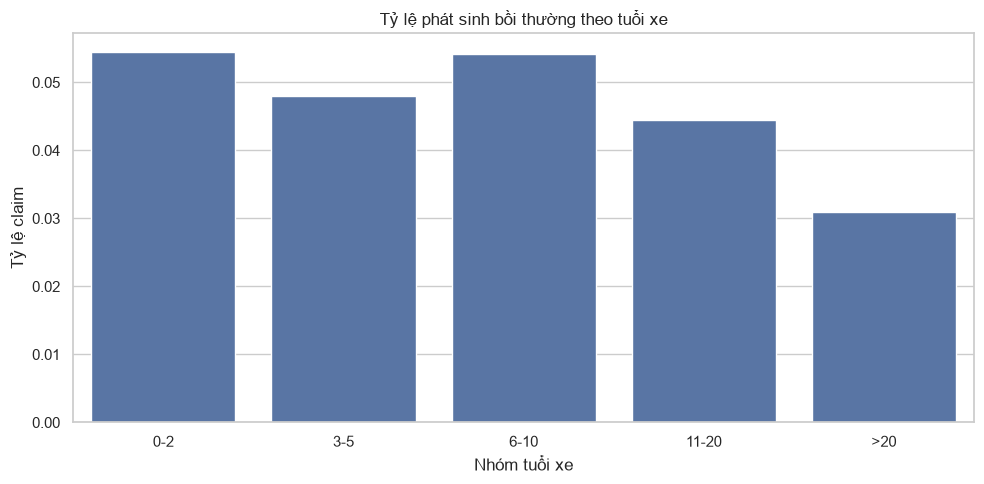

In [10]:
# =========================================================
# 5. PHÂN TÍCH TUỔI XE
# =========================================================

df_vehage = df.copy()

df_vehage["Vehicle_Age_Group"] = pd.cut(
    df_vehage["VehAge"],
    bins=[-1, 2, 5, 10, 20, np.inf],
    labels=[
        "0-2",
        "3-5",
        "6-10",
        "11-20",
        ">20"
    ]
)

vehage_analysis = (
    df_vehage
    .groupby("Vehicle_Age_Group", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

vehage_analysis["Claim_Rate"] = (
    df_vehage
    .groupby("Vehicle_Age_Group", observed=False)["IsClaim"]
    .mean()
    .values
)

vehage_analysis["Frequency"] = (
    vehage_analysis["Claims"] /
    vehage_analysis["Exposure"]
)

vehage_analysis["Pure_Premium"] = (
    vehage_analysis["ClaimAmount"] /
    vehage_analysis["Exposure"]
)

display(
    vehage_analysis.round(4)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    data=vehage_analysis,
    x="Vehicle_Age_Group",
    y="Claim_Rate"
)

plt.title("Tỷ lệ phát sinh bồi thường theo tuổi xe")
plt.xlabel("Nhóm tuổi xe")
plt.ylabel("Tỷ lệ claim")

plt.tight_layout()
plt.show()


--- Phân tích theo Bonus-Malus ---


,BonusMalus_Group,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,≤60,478602,273218.6279,22609,29307814.4300,0.0449,0.0828,107.2687
1,61-80,118755,53065.3468,7057,12233864.6800,0.0558,0.1330,230.5434
2,81-100,72862,28644.1518,5094,15807607.8300,0.0650,0.1778,551.8616
3,101-120,5554,2573.0030,873,1568366.0600,0.1442,0.3393,609.5469
4,>120,2240,998.3160,469,991563.5000,0.1839,0.4698,993.2361


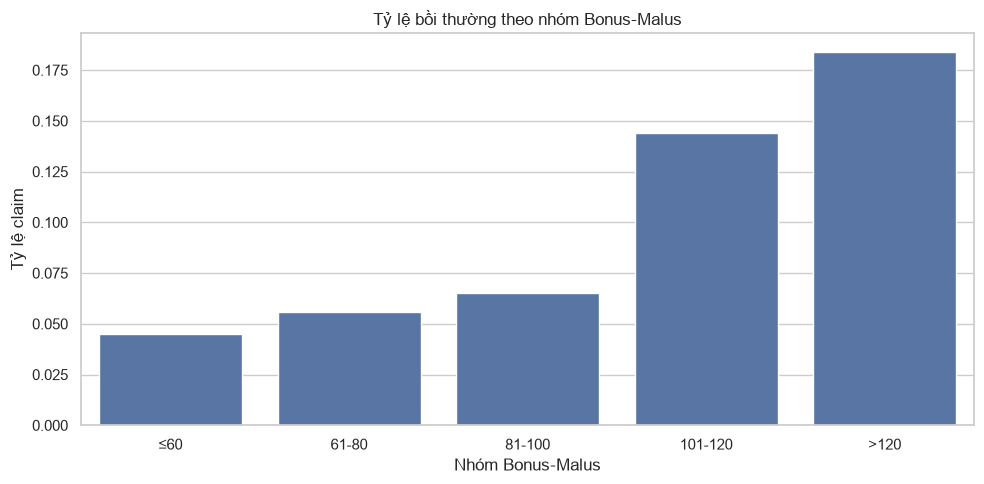

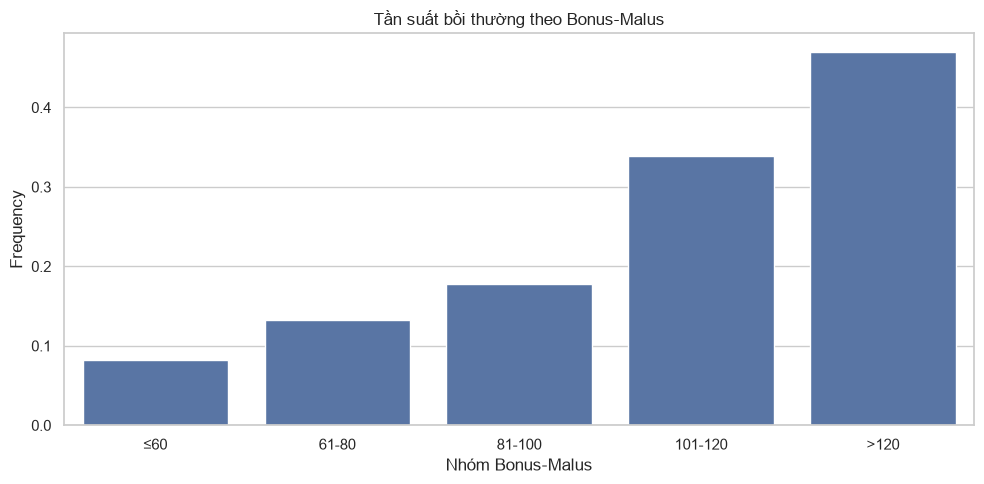

In [11]:
# =========================================================
# 6. PHÂN TÍCH BONUS-MALUS
# =========================================================

df_bm = df.copy()

df_bm["BonusMalus_Group"] = pd.cut(
    df_bm["BonusMalus"],
    bins=[0, 60, 80, 100, 120, np.inf],
    labels=[
        "≤60",
        "61-80",
        "81-100",
        "101-120",
        ">120"
    ],
    include_lowest=True
)

bm_analysis = (
    df_bm
    .groupby("BonusMalus_Group", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

bm_analysis["Claim_Rate"] = (
    df_bm
    .groupby("BonusMalus_Group", observed=False)["IsClaim"]
    .mean()
    .values
)

bm_analysis["Frequency"] = (
    bm_analysis["Claims"] /
    bm_analysis["Exposure"]
)

bm_analysis["Pure_Premium"] = (
    bm_analysis["ClaimAmount"] /
    bm_analysis["Exposure"]
)

print("\n--- Phân tích theo Bonus-Malus ---")
display(
    bm_analysis.round(4)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    data=bm_analysis,
    x="BonusMalus_Group",
    y="Claim_Rate"
)

plt.title("Tỷ lệ bồi thường theo nhóm Bonus-Malus")
plt.xlabel("Nhóm Bonus-Malus")
plt.ylabel("Tỷ lệ claim")

plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=bm_analysis,
    x="BonusMalus_Group",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo Bonus-Malus")
plt.xlabel("Nhóm Bonus-Malus")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


--- Phân tích theo loại nhiên liệu ---


,VehGas,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,'Diesel',332136,170660.8931,16648,27594673.9500,0.0473,0.0976,161.6930
1,'Regular',345877,187838.5523,19454,32314542.5500,0.0531,0.1036,172.0336


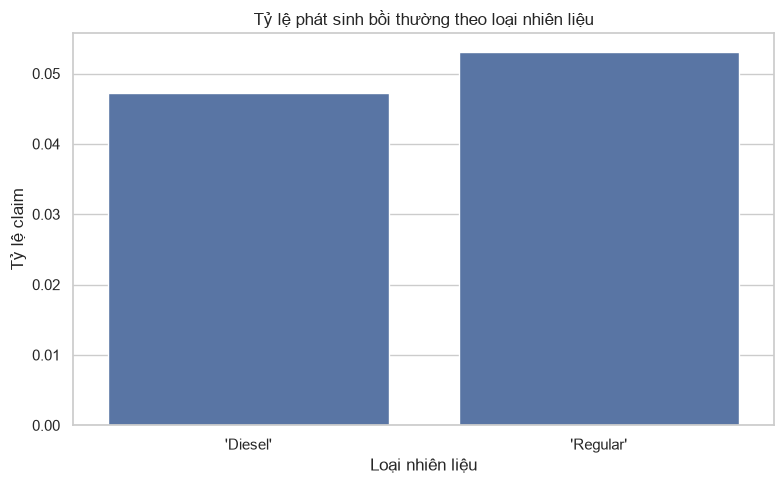

In [12]:
# =========================================================
# 7. PHÂN TÍCH LOẠI NHIÊN LIỆU
# =========================================================

fuel_analysis = (
    df
    .groupby("VehGas")
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

fuel_analysis["Claim_Rate"] = (
    df
    .groupby("VehGas")["IsClaim"]
    .mean()
    .values
)

fuel_analysis["Frequency"] = (
    fuel_analysis["Claims"] /
    fuel_analysis["Exposure"]
)

fuel_analysis["Pure_Premium"] = (
    fuel_analysis["ClaimAmount"] /
    fuel_analysis["Exposure"]
)

print("\n--- Phân tích theo loại nhiên liệu ---")
display(
    fuel_analysis.round(4)
)
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fuel_analysis,
    x="VehGas",
    y="Claim_Rate"
)

plt.title("Tỷ lệ phát sinh bồi thường theo loại nhiên liệu")
plt.xlabel("Loại nhiên liệu")
plt.ylabel("Tỷ lệ claim")

plt.tight_layout()
plt.show()


--- Phân tích theo thương hiệu xe ---


,VehBrand,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
3,B12,166024,64808.6087,8859,8747094.5800,0.0497,0.1367,134.9681
2,B11,13585,6887.8173,721,2228920.3700,0.0501,0.1047,323.6033
9,B5,34753,19992.0627,2020,2901047.9300,0.0551,0.1010,145.1100
7,B3,53395,28592.8763,2818,5197982.0700,0.0500,0.0986,181.7929
4,B13,12178,6772.0322,649,1161629.5600,0.0503,0.0958,171.5334
8,B4,25179,13775.4961,1312,2546351.2100,0.0498,0.0952,184.8464
10,B6,28548,15684.9536,1462,1957513.7400,0.0486,0.0932,124.8020
0,B1,162736,95351.0596,8677,14462378.1400,0.0502,0.0910,151.6751
1,B10,17707,9496.0141,858,1683301.3100,0.0461,0.0904,177.2640
6,B2,159861,94864.0571,8560,18801244.9000,0.0508,0.0902,198.1914


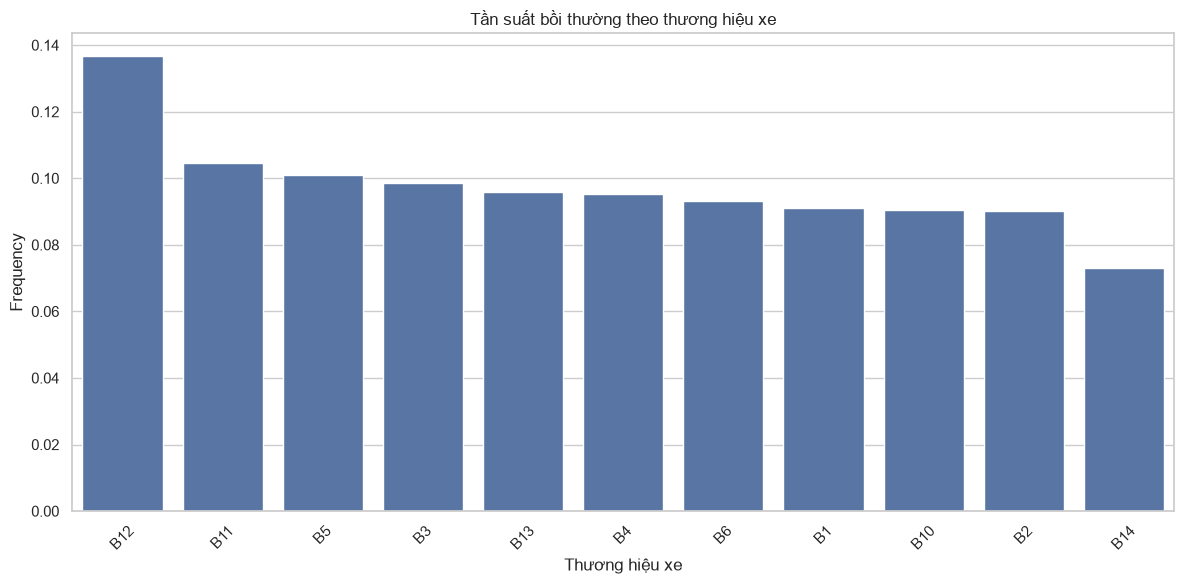

In [13]:
# =========================================================
# 8. PHÂN TÍCH THƯƠNG HIỆU XE
# =========================================================

brand_analysis = (
    df
    .groupby("VehBrand")
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

brand_analysis["Claim_Rate"] = (
    df
    .groupby("VehBrand")["IsClaim"]
    .mean()
    .values
)

brand_analysis["Frequency"] = (
    brand_analysis["Claims"] /
    brand_analysis["Exposure"]
)

brand_analysis["Pure_Premium"] = (
    brand_analysis["ClaimAmount"] /
    brand_analysis["Exposure"]
)

# Loại các brand có quá ít dữ liệu
brand_plot = (
    brand_analysis[
        brand_analysis["Policies"] >= 1000
    ]
    .sort_values("Frequency", ascending=False)
)

print("\n--- Phân tích theo thương hiệu xe ---")
display(
    brand_plot.round(4)
)
plt.figure(figsize=(12, 6))

sns.barplot(
    data=brand_plot,
    x="VehBrand",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo thương hiệu xe")
plt.xlabel("Thương hiệu xe")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


--- Phân tích theo Region ---


,Region,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
21,R94,4516,1765.9354,247,464582.5500,0.0487,0.1399,263.0802
1,R21,3026,1205.8315,160,481248.3400,0.0492,0.1327,399.1008
0,R11,69791,30208.6420,3978,4563221.8600,0.0532,0.1317,151.0568
2,R22,7994,3574.4102,439,687624.8700,0.0527,0.1228,192.3744
17,R82,84752,45347.4173,5032,10278303.8500,0.0562,0.1110,226.6569
9,R42,2200,1209.1158,133,121424.9900,0.0564,0.1100,100.4246
20,R93,79315,35790.3210,3907,6871024.8000,0.0457,0.1092,191.9800
16,R74,4567,2395.9945,259,280285.1400,0.0530,0.1081,116.9807
19,R91,35805,14736.1042,1547,2030911.0800,0.0388,0.1050,137.8187
7,R31,27285,11497.9743,1176,1634689.7200,0.0400,0.1023,142.1720


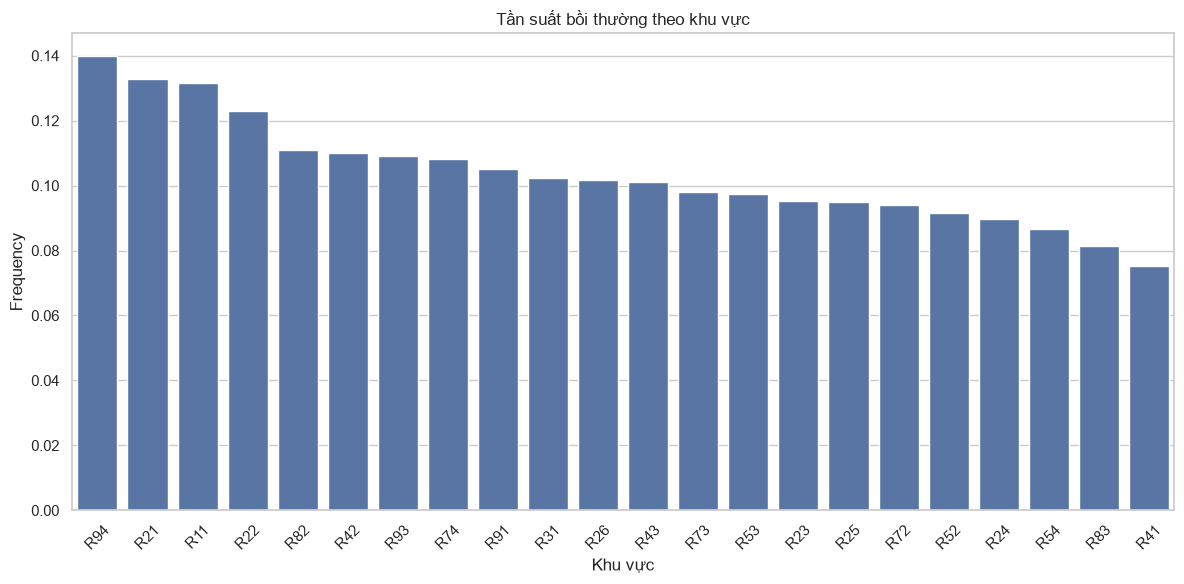

In [14]:
# =========================================================
# 9. PHÂN TÍCH KHU VỰC
# =========================================================

region_analysis = (
    df
    .groupby("Region")
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

region_analysis["Claim_Rate"] = (
    df
    .groupby("Region")["IsClaim"]
    .mean()
    .values
)

region_analysis["Frequency"] = (
    region_analysis["Claims"] /
    region_analysis["Exposure"]
)

region_analysis["Pure_Premium"] = (
    region_analysis["ClaimAmount"] /
    region_analysis["Exposure"]
)

region_plot = (
    region_analysis[
        region_analysis["Policies"] >= 500
    ]
    .sort_values("Frequency", ascending=False)
)

print("\n--- Phân tích theo Region ---")
display(
    region_plot.round(4)
)
plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_plot,
    x="Region",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo khu vực")
plt.xlabel("Khu vực")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


--- Phân tích theo mật độ dân số ---


,Density_Group,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,Rất thấp,137340,81409.0096,6753,10081880.2000,0.0469,0.0830,123.8423
1,Thấp,134178,74104.3796,6743,13954250.5200,0.0478,0.0910,188.3053
2,Trung bình,135398,72041.1316,7091,9956455.9100,0.0495,0.0984,138.2052
3,Cao,137845,69486.2039,7855,14010243.8600,0.0532,0.1130,201.6263
4,Rất cao,133252,61458.7208,7660,11906386.0100,0.0538,0.1246,193.7298


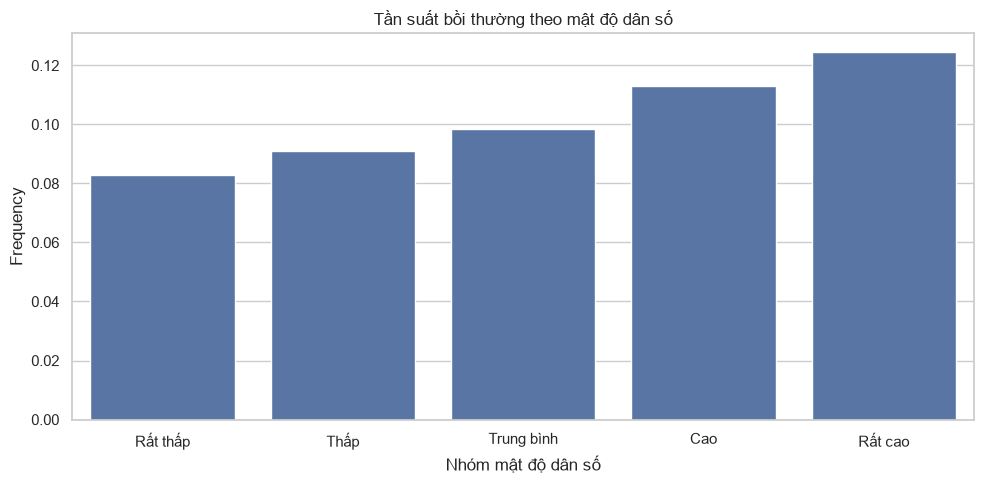

In [15]:
# =========================================================
# 10. PHÂN TÍCH MẬT ĐỘ DÂN SỐ
# =========================================================

df_density = df.copy()

df_density["Density_Group"] = pd.qcut(
    df_density["Density"],
    q=5,
    labels=[
        "Rất thấp",
        "Thấp",
        "Trung bình",
        "Cao",
        "Rất cao"
    ],
    duplicates="drop"
)

density_analysis = (
    df_density
    .groupby("Density_Group", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

density_analysis["Claim_Rate"] = (
    df_density
    .groupby("Density_Group", observed=False)["IsClaim"]
    .mean()
    .values
)

density_analysis["Frequency"] = (
    density_analysis["Claims"] /
    density_analysis["Exposure"]
)

density_analysis["Pure_Premium"] = (
    density_analysis["ClaimAmount"] /
    density_analysis["Exposure"]
)

print("\n--- Phân tích theo mật độ dân số ---")
display(
    density_analysis.round(4)
)
plt.figure(figsize=(10, 5))

sns.barplot(
    data=density_analysis,
    x="Density_Group",
    y="Frequency"
)

plt.title("Tần suất bồi thường theo mật độ dân số")
plt.xlabel("Nhóm mật độ dân số")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


--- Tương tác tuổi và Bonus-Malus ---


,Age_Group,BonusMalus_Group,Policies,Exposure,Claims,ClaimAmount,Claim_Rate,Frequency,Pure_Premium
0,<25,≤80,12028,5845.2100,535,889612.0400,0.0418,0.0915,152.1951
1,<25,81-100,24042,9121.2544,1788,10403059.2000,0.0685,0.1960,1140.5294
2,<25,>100,2825,1261.4388,518,1014590.3000,0.1674,0.4106,804.3119
3,25-40,≤80,198672,98587.8381,8009,12682106.0200,0.0384,0.0812,128.6376
4,25-40,81-100,33768,13084.1786,2119,3668107.6200,0.0587,0.1620,280.3468
5,25-40,>100,3251,1445.5161,487,953919.3900,0.1363,0.3369,659.9161
6,41-60,≤80,286178,157881.6538,15235,19547111.5900,0.0503,0.0965,123.8086
7,41-60,81-100,12680,5333.5030,981,1423098.2600,0.0725,0.1839,266.8224
8,41-60,>100,1341,650.7894,241,411373.5000,0.1588,0.3703,632.1146
9,>60,≤80,100479,63969.2727,5887,8422849.4600,0.0554,0.0920,131.6702


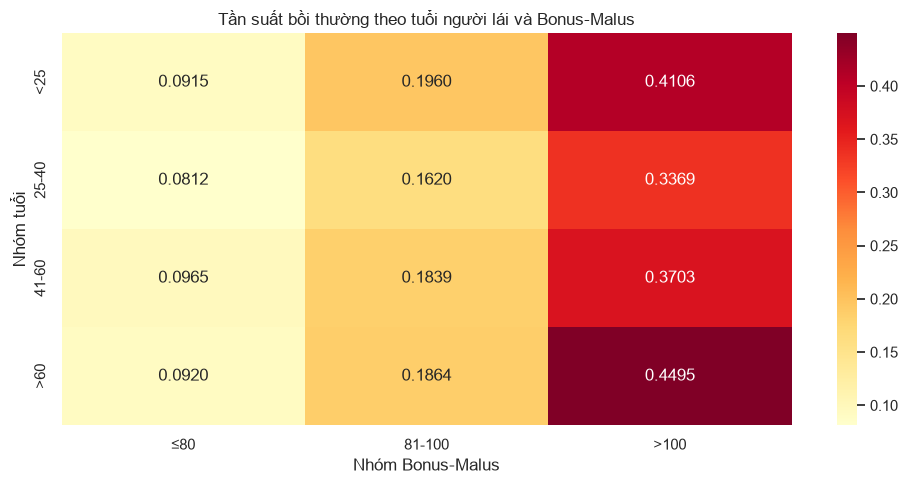

In [16]:
# =========================================================
# 11. TƯƠNG TÁC TUỔI × BONUS-MALUS
# =========================================================

df_interaction = df.copy()

df_interaction["Age_Group"] = pd.cut(
    df_interaction["DrivAge"],
    bins=[0, 25, 40, 60, 100],
    labels=[
        "<25",
        "25-40",
        "41-60",
        ">60"
    ],
    include_lowest=True
)

df_interaction["BonusMalus_Group"] = pd.cut(
    df_interaction["BonusMalus"],
    bins=[0, 80, 100, np.inf],
    labels=[
        "≤80",
        "81-100",
        ">100"
    ],
    include_lowest=True
)

interaction_analysis = (
    df_interaction
    .groupby(
        ["Age_Group", "BonusMalus_Group"],
        observed=False
    )
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum"),
        ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)

interaction_analysis["Claim_Rate"] = (
    df_interaction
    .groupby(
        ["Age_Group", "BonusMalus_Group"],
        observed=False
    )["IsClaim"]
    .mean()
    .values
)

interaction_analysis["Frequency"] = (
    interaction_analysis["Claims"] /
    interaction_analysis["Exposure"]
)

interaction_analysis["Pure_Premium"] = (
    interaction_analysis["ClaimAmount"] /
    interaction_analysis["Exposure"]
)

print("\n--- Tương tác tuổi và Bonus-Malus ---")

display(
    interaction_analysis.round(4)
)
pivot_frequency = interaction_analysis.pivot(
    index="Age_Group",
    columns="BonusMalus_Group",
    values="Frequency"
)

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot_frequency,
    annot=True,
    fmt=".4f",
    cmap="YlOrRd"
)

plt.title(
    "Tần suất bồi thường theo tuổi người lái và Bonus-Malus"
)

plt.xlabel("Nhóm Bonus-Malus")
plt.ylabel("Nhóm tuổi")

plt.tight_layout()
plt.show()

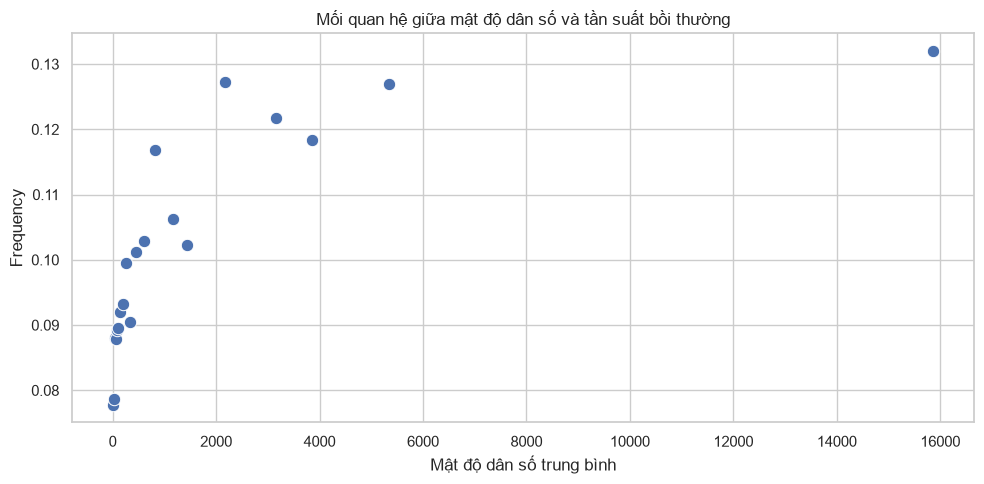

In [17]:
# =========================================================
# 12. DENSITY × FREQUENCY
# =========================================================

density_relationship = (
    df.groupby(
        pd.qcut(
            df["Density"],
            q=20,
            duplicates="drop"
        ),
        observed=False
    )
    .agg(
        Avg_Density=("Density", "mean"),
        Exposure=("Exposure", "sum"),
        Claims=("ClaimNb", "sum")
    )
    .reset_index()
)

density_relationship["Frequency"] = (
    density_relationship["Claims"] /
    density_relationship["Exposure"]
)
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=density_relationship,
    x="Avg_Density",
    y="Frequency",
    s=80
)

plt.title(
    "Mối quan hệ giữa mật độ dân số và tần suất bồi thường"
)

plt.xlabel("Mật độ dân số trung bình")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


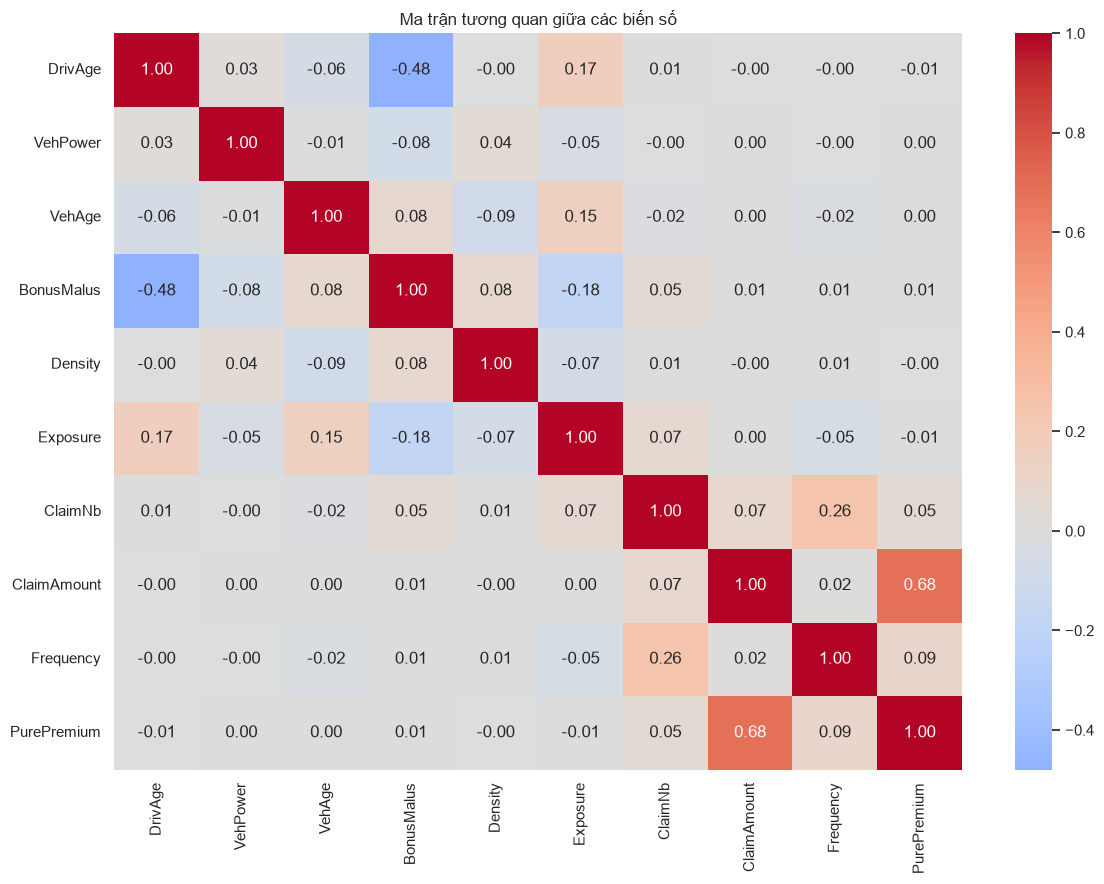

In [18]:
# =========================================================
# 13. CORRELATION HEATMAP
# =========================================================

corr_cols = [
    "DrivAge",
    "VehPower",
    "VehAge",
    "BonusMalus",
    "Density",
    "Exposure",
    "ClaimNb",
    "ClaimAmount",
    "Frequency",
    "PurePremium"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Ma trận tương quan giữa các biến số"
)

plt.tight_layout()
plt.show()

In [19]:
# =========================================================
# 14. TỔNG HỢP CÁC FEATURE
# =========================================================

summary_eda = pd.DataFrame({

    "Feature": [

        "DrivAge",
        "BonusMalus",
        "VehPower",
        "VehAge",
        "VehBrand",
        "VehGas",
        "Area",
        "Region",
        "Density",
        "Exposure"

    ],

    "Ý nghĩa": [

        "Tuổi người lái",
        "Hệ số Bonus-Malus",
        "Công suất xe",
        "Tuổi xe",
        "Thương hiệu xe",
        "Loại nhiên liệu",
        "Khu vực",
        "Vùng địa lý",
        "Mật độ dân số",
        "Thời gian bảo hiểm"

    ],

    "Loại dữ liệu": [

        "Numerical",
        "Numerical",
        "Numerical",
        "Numerical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numerical",
        "Numerical"

    ]

})

display(summary_eda)

,Feature,Ý nghĩa,Loại dữ liệu
0,DrivAge,Tuổi người lái,Numerical
1,BonusMalus,Hệ số Bonus-Malus,Numerical
2,VehPower,Công suất xe,Numerical
3,VehAge,Tuổi xe,Numerical
4,VehBrand,Thương hiệu xe,Categorical
5,VehGas,Loại nhiên liệu,Categorical
6,Area,Khu vực,Categorical
7,Region,Vùng địa lý,Categorical
8,Density,Mật độ dân số,Numerical
9,Exposure,Thời gian bảo hiểm,Numerical


In [20]:
# =========================================================
# 15. TÓM TẮT CÁC NHÓM CÓ GIÁ TRỊ CAO
# =========================================================

print("=" * 100)
print("TÓM TẮT EDA")
print("=" * 100)

print("\n1. Nhóm tuổi có Claim Rate cao nhất:")
display(
    age_analysis
    .sort_values(
        "Claim_Rate",
        ascending=False
    )
    .head(3)[
        [
            "Age_Group",
            "Claim_Rate",
            "Frequency",
            "Pure_Premium"
        ]
    ]
)

print("\n2. Nhóm công suất xe có Frequency cao nhất:")
display(
    power_analysis
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(3)[
        [
            "Power_Group",
            "Claim_Rate",
            "Frequency",
            "Pure_Premium"
        ]
    ]
)

print("\n3. Nhóm tuổi xe có Frequency cao nhất:")
display(
    vehage_analysis
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(3)[
        [
            "Vehicle_Age_Group",
            "Claim_Rate",
            "Frequency",
            "Pure_Premium"
        ]
    ]
)

print("\n4. Nhóm Bonus-Malus có Frequency cao nhất:")
display(
    bm_analysis
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(3)[
        [
            "BonusMalus_Group",
            "Claim_Rate",
            "Frequency",
            "Pure_Premium"
        ]
    ]
)

print("\n5. Nhóm mật độ dân số có Frequency cao nhất:")
display(
    density_analysis
    .sort_values(
        "Frequency",
        ascending=False
    )
    .head(3)[
        [
            "Density_Group",
            "Claim_Rate",
            "Frequency",
            "Pure_Premium"
        ]
    ]
)

TÓM TẮT EDA

1. Nhóm tuổi có Claim Rate cao nhất:


,Age_Group,Claim_Rate,Frequency,Pure_Premium
0,<25,0.0674,0.1751,758.4012
5,>60,0.0565,0.0948,136.5677
3,41-50,0.0526,0.1040,131.9837



2. Nhóm công suất xe có Frequency cao nhất:


,Power_Group,Claim_Rate,Frequency,Pure_Premium
0,≤50,0.0502,0.1007,167.1110
1,51-75,NaN,NaN,NaN
2,76-100,NaN,NaN,NaN



3. Nhóm tuổi xe có Frequency cao nhất:


,Vehicle_Age_Group,Claim_Rate,Frequency,Pure_Premium
0,0-2,0.0545,0.1377,155.3457
2,6-10,0.0542,0.0994,159.6328
1,3-5,0.0479,0.0936,146.4864



4. Nhóm Bonus-Malus có Frequency cao nhất:


,BonusMalus_Group,Claim_Rate,Frequency,Pure_Premium
4,>120,0.1839,0.4698,993.2361
3,101-120,0.1442,0.3393,609.5469
2,81-100,0.0650,0.1778,551.8616



5. Nhóm mật độ dân số có Frequency cao nhất:


,Density_Group,Claim_Rate,Frequency,Pure_Premium
4,Rất cao,0.0538,0.1246,193.7298
3,Cao,0.0532,0.1130,201.6263
2,Trung bình,0.0495,0.0984,138.2052


In [21]:
# =========================================================
# 16. TỔNG HỢP INSIGHT THEO YẾU TỐ
# =========================================================

eda_comparison = pd.DataFrame({

    "Yếu tố": [
        "Tuổi người lái",
        "Công suất xe",
        "Tuổi xe",
        "Bonus-Malus"
    ],

    "Nhóm rủi ro cao nhất": [
        age_analysis.loc[
            age_analysis["Claim_Rate"].idxmax(),
            "Age_Group"
        ],

        power_analysis.loc[
            power_analysis["Claim_Rate"].idxmax(),
            "Power_Group"
        ],

        vehage_analysis.loc[
            vehage_analysis["Claim_Rate"].idxmax(),
            "Vehicle_Age_Group"
        ],

        bm_analysis.loc[
            bm_analysis["Claim_Rate"].idxmax(),
            "BonusMalus_Group"
        ]
    ],

    "Claim Rate cao nhất": [
        age_analysis["Claim_Rate"].max(),
        power_analysis["Claim_Rate"].max(),
        vehage_analysis["Claim_Rate"].max(),
        bm_analysis["Claim_Rate"].max()
    ]

})

display(
    eda_comparison.round(4)
)

,Yếu tố,Nhóm rủi ro cao nhất,Claim Rate cao nhất
0,Tuổi người lái,<25,0.0674
1,Công suất xe,≤50,0.0502
2,Tuổi xe,0-2,0.0545
3,Bonus-Malus,>120,0.1839


## 4. Chia Train / Calibration / Validation / Test

- **Train:** huấn luyện model và fitting calibration theo CV.
- **Validation:** chọn threshold và early stopping.
- **Test:** chỉ đánh giá cuối cùng.

Test không được dùng để tune hyperparameter, calibration hoặc chọn threshold.

In [22]:
idx = df.index

idx_train, idx_test = train_test_split(
    idx,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df.loc[idx, "IsClaim"]
)
idx_train, idx_valid = train_test_split(
    idx_train,
    test_size=0.1764705882,  # 0.15 tổng dữ liệu / 0.85 phần còn lại
    random_state=RANDOM_STATE,
    stratify=df.loc[idx_train, "IsClaim"]
)

train_df = df.loc[idx_train].copy()
valid_df = df.loc[idx_valid].copy()
test_df = df.loc[idx_test].copy()

print(f"Train: {len(train_df):,} ({len(train_df)/len(df):.1%})")
print(f"Validation: {len(valid_df):,} ({len(valid_df)/len(df):.1%})")
print(f"Test: {len(test_df):,} ({len(test_df)/len(df):.1%})")
print("Claim rate:")
print(pd.Series({
    "Train": train_df["IsClaim"].mean(),
    "Validation": valid_df["IsClaim"].mean(),
    "Test": test_df["IsClaim"].mean()
}))

X_train = train_df[feature_cols].copy()
X_valid = valid_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_class = train_df["IsClaim"].copy()
y_valid_class = valid_df["IsClaim"].copy()
y_test_class = test_df["IsClaim"].copy()

w_train = train_df["Exposure"].copy()
w_valid = valid_df["Exposure"].copy()
w_test = test_df["Exposure"].copy()

y_train_tweedie = train_df["PurePremium"].copy()
y_valid_tweedie = valid_df["PurePremium"].copy()
y_test_tweedie = test_df["PurePremium"].copy()

Train: 474,609 (70.0%)
Validation: 101,702 (15.0%)
Test: 101,702 (15.0%)
Claim rate:
Train        0.0502
Validation   0.0502
Test         0.0502
dtype: float64


## 5. Preprocessor cho GLM / Random Forest

CatBoost sẽ **không** dùng One-Hot Encoding; categorical variables được truyền trực tiếp cho CatBoost.

In [23]:
num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_valid_preprocessed = preprocessor.transform(X_valid)
X_test_preprocessed = preprocessor.transform(X_test)

print("Shape sau preprocessing:")
print("Train:", X_train_preprocessed.shape)
print("Valid:", X_valid_preprocessed.shape)
print("Test:", X_test_preprocessed.shape)

Shape sau preprocessing:
Train: (474609, 48)
Valid: (101702, 48)
Test: (101702, 48)


# PHẦN A — RISK MODELING: XÁC SUẤT XẢY RA CLAIM

## 6. Random Forest Classifier

Random Forest dùng `class_weight='balanced'` như benchmark cho dữ liệu lệch lớp. Không dùng SMOTE mặc định vì dữ liệu bảo hiểm còn có Exposure và cấu trúc zero-inflation.

In [24]:
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    class_weight="balanced",
    max_samples=0.6,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_classifier.fit(X_train_preprocessed, y_train_class)
rf_valid_prob = rf_classifier.predict_proba(X_valid_preprocessed)[:, 1]
rf_test_prob = rf_classifier.predict_proba(X_test_preprocessed)[:, 1]

print("RF validation ROC-AUC:", roc_auc_score(y_valid_class, rf_valid_prob))
print("RF test ROC-AUC:", roc_auc_score(y_test_class, rf_test_prob))

RF validation ROC-AUC: 0.6537331321254705
RF test ROC-AUC: 0.6539233311330416


## 7. CatBoost Classifier + calibration

CatBoost được huấn luyện trực tiếp trên categorical features. Calibration dùng **out-of-fold predictions trên Train + Logistic/Platt calibration**, sau đó CatBoost được refit trên toàn bộ Train. Validation chỉ dùng để chọn threshold, Test chỉ dùng để đánh giá cuối cùng.

In [25]:
# CatBoost Risk Model dùng categorical features trực tiếp.
# Không dùng class weight trong model xác suất cuối vì class weighting có thể làm lệch probability calibration.
cat_risk_params = dict(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    l2_leaf_reg=5
)

# OOF probabilities trên Train để học calibrator mà không nhìn thấy nhãn của chính fold đó.
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
oof_prob = np.zeros(len(X_train), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train_class), start=1):
    model_fold = CatBoostClassifier(**cat_risk_params)
    model_fold.fit(
        X_train.iloc[tr_idx],
        y_train_class.iloc[tr_idx],
        cat_features=cat_features
    )
    oof_prob[va_idx] = model_fold.predict_proba(X_train.iloc[va_idx])[:, 1]

# Platt-style calibration: chỉ học trên OOF predictions của Train.
prob_calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
prob_calibrator.fit(oof_prob.reshape(-1, 1), y_train_class)

# Refit CatBoost trên toàn bộ Train sau khi calibration đã được học.
cat_risk_model = CatBoostClassifier(**cat_risk_params)
cat_risk_model.fit(
    X_train,
    y_train_class,
    cat_features=cat_features
)

cat_valid_raw_prob = cat_risk_model.predict_proba(X_valid)[:, 1]
cat_test_raw_prob = cat_risk_model.predict_proba(X_test)[:, 1]
cat_valid_prob = prob_calibrator.predict_proba(cat_valid_raw_prob.reshape(-1, 1))[:, 1]
cat_test_prob = prob_calibrator.predict_proba(cat_test_raw_prob.reshape(-1, 1))[:, 1]

print("CatBoost calibrated validation ROC-AUC:", roc_auc_score(y_valid_class, cat_valid_prob))
print("CatBoost calibrated test ROC-AUC:", roc_auc_score(y_test_class, cat_test_prob))

CatBoost calibrated validation ROC-AUC: 0.6597308457292227
CatBoost calibrated test ROC-AUC: 0.6601236633573859


## 8. Chọn threshold chỉ trên Validation

In [26]:
def youden_threshold(y_true, prob):
    fpr, tpr, thresholds = roc_curve(y_true, prob)
    j = tpr - fpr
    j_idx = int(np.nanargmax(j))
    return float(thresholds[j_idx]), float(fpr[j_idx]), float(tpr[j_idx]), float(j[j_idx])

cat_threshold, valid_fpr, valid_tpr, valid_j = youden_threshold(y_valid_class, cat_valid_prob)
rf_threshold, rf_valid_fpr, rf_valid_tpr, rf_valid_j = youden_threshold(y_valid_class, rf_valid_prob)

print(f"CatBoost threshold (Validation / Youden): {cat_threshold:.4f}")
print(f"RF threshold (Validation / Youden): {rf_threshold:.4f}")
print(f"CatBoost validation J: {valid_j:.4f}")
print(f"RF validation J: {rf_valid_j:.4f}")

CatBoost threshold (Validation / Youden): 0.0454
RF threshold (Validation / Youden): 0.4952
CatBoost validation J: 0.2275
RF validation J: 0.2213


## 9. Đánh giá Risk Model trên Test

              Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC  Brier   Gini
      Random Forest     0.4952    0.7177     0.0864  0.4825 0.1466   0.6539  0.1055 0.2264 0.3078
CatBoost Calibrated     0.0454    0.6575     0.0811  0.5633 0.1418   0.6601  0.1179 0.0466 0.3202


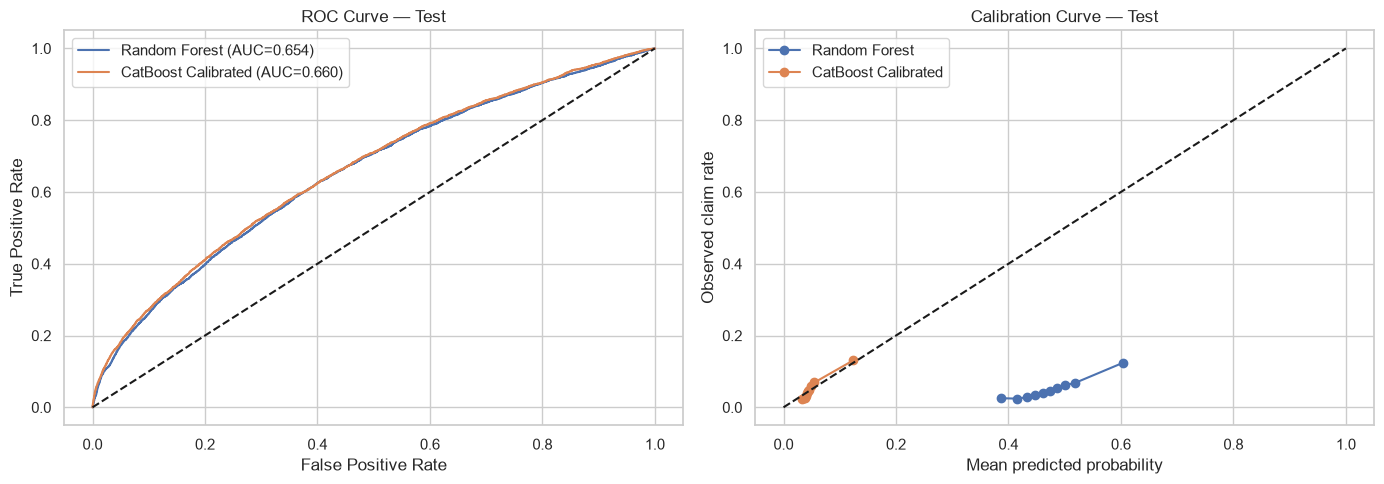

In [27]:
def classification_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "PR-AUC": average_precision_score(y_true, prob),
        "Brier": brier_score_loss(y_true, prob),
        "Gini": 2 * roc_auc_score(y_true, prob) - 1,
    }

risk_results = pd.DataFrame([
    {"Model": "Random Forest", **classification_metrics(y_test_class, rf_test_prob, rf_threshold)},
    {"Model": "CatBoost Calibrated", **classification_metrics(y_test_class, cat_test_prob, cat_threshold)}
])

print(risk_results.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, prob in [("Random Forest", rf_test_prob), ("CatBoost Calibrated", cat_test_prob)]:
    fpr, tpr, _ = roc_curve(y_test_class, prob)
    auc = roc_auc_score(y_test_class, prob)
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC Curve — Test")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Calibration curve được đánh giá trên Test; calibrator đã được fit trên Train.
for model_name, prob in [("Random Forest", rf_test_prob), ("CatBoost Calibrated", cat_test_prob)]:
    frac_pos, mean_pred = calibration_curve(y_test_class, prob, n_bins=10, strategy="quantile")
    axes[1].plot(mean_pred, frac_pos, "o-", label=model_name)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("Calibration Curve — Test")
axes[1].set_xlabel("Mean predicted probability")
axes[1].set_ylabel("Observed claim rate")
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Risk decile scorecard trên Test

Decile chỉ được dùng sau khi model và threshold/calibration đã được khóa từ Train/Validation.

Decile  Policies  Exposure  Avg_Predicted_Prob  Actual_Claim_Rate  Claims  Actual_ClaimAmount  Observed_Frequency_per_Exposure  O_E_Probability
    D1     10171 4881.8395              0.0336             0.0218     237         709008.3700                           0.0485           0.6494
    D2     10170 5041.4130              0.0360             0.0270     291         765914.2000                           0.0577           0.7520
    D3     10170 5255.7364              0.0377             0.0270     297         371247.3100                           0.0565           0.7182
    D4     10170 5304.2581              0.0394             0.0320     348         909175.4300                           0.0656           0.8114
    D5     10170 5508.1453              0.0412             0.0411     462         645892.4600                           0.0839           0.9975
    D6     10170 5623.0750              0.0431             0.0460     499         704993.6800                           0.0887          

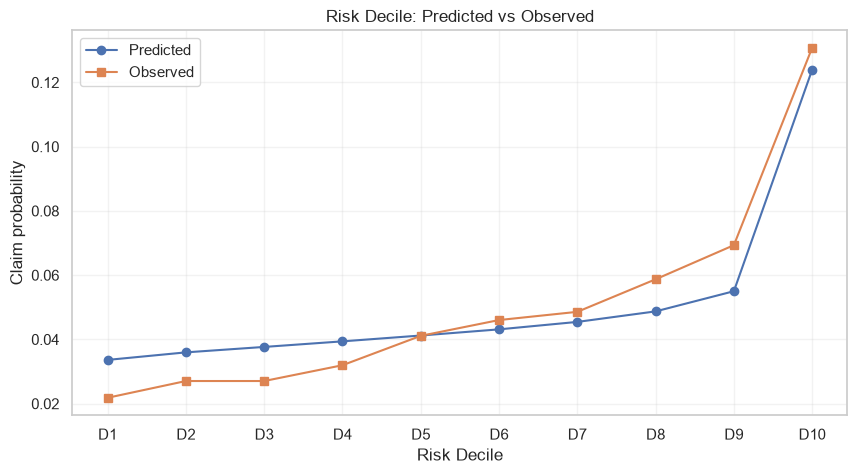

In [28]:
df_decile = test_df[["IDpol", "Exposure", "ClaimNb", "ClaimAmount"]].copy()
df_decile["Predicted_Prob"] = cat_test_prob
# D1 = rủi ro thấp nhất, D10 = rủi ro cao nhất.
# Rank trước khi qcut để tránh lỗi khi nhiều probability bị trùng.
ranked_prob = df_decile["Predicted_Prob"].rank(method="first")
df_decile["Decile"] = pd.qcut(
    ranked_prob,
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)
df_decile["Actual_Claim"] = (df_decile["ClaimNb"] > 0).astype(int)

decile_summary = (
    df_decile.groupby("Decile", observed=False)
    .agg(
        Policies=("IDpol", "count"),
        Exposure=("Exposure", "sum"),
        Avg_Predicted_Prob=("Predicted_Prob", "mean"),
        Actual_Claim_Rate=("Actual_Claim", "mean"),
        Claims=("ClaimNb", "sum"),
        Actual_ClaimAmount=("ClaimAmount", "sum")
    )
    .reset_index()
)
decile_summary["Observed_Frequency_per_Exposure"] = (
    decile_summary["Claims"] / decile_summary["Exposure"]
)
decile_summary["O_E_Probability"] = (
    decile_summary["Actual_Claim_Rate"] / decile_summary["Avg_Predicted_Prob"]
)

print(decile_summary.round(4).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.plot(decile_summary["Decile"].astype(str), decile_summary["Avg_Predicted_Prob"], "o-", label="Predicted")
plt.plot(decile_summary["Decile"].astype(str), decile_summary["Actual_Claim_Rate"], "s-", label="Observed")
plt.xlabel("Risk Decile")
plt.ylabel("Claim probability")
plt.title("Risk Decile: Predicted vs Observed")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# PHẦN B — PRICING MODELING: PURE PREMIUM

## 11. Tune Tweedie bằng Cross-Validation trên Train בלבד

Optuna không được nhìn thấy Test. Để giảm thời gian chạy với dataset lớn, tuning dùng một mẫu tối đa 120.000 policy từ Train; sau khi chọn hyperparameter, model được refit trên toàn bộ Train + Validation.

In [29]:
# Lấy mẫu tuning cố định, chỉ từ Train.
tune_n = min(120_000, len(train_df))
tune_df = train_df.sample(n=tune_n, random_state=RANDOM_STATE)
X_tune = preprocessor.transform(tune_df[feature_cols])
y_tune = tune_df["PurePremium"].to_numpy()
w_tune = tune_df["Exposure"].to_numpy()

cv_price = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def objective_tweedie(trial):
    power = trial.suggest_float("power", 1.1, 1.9)
    alpha = trial.suggest_float("alpha", 1e-4, 10.0, log=True)
    fold_scores = []
    for tr_idx, va_idx in cv_price.split(X_tune):
        model = TweedieRegressor(power=power, alpha=alpha, max_iter=1000)
        model.fit(X_tune[tr_idx], y_tune[tr_idx], sample_weight=w_tune[tr_idx])
        pred = np.clip(model.predict(X_tune[va_idx]), 1e-9, None)
        score = mean_tweedie_deviance(
            y_tune[va_idx], pred, power=power, sample_weight=w_tune[va_idx]
        )
        fold_scores.append(score)
    return float(np.mean(fold_scores))

study_tweedie = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_tweedie.optimize(objective_tweedie, n_trials=15, show_progress_bar=False)

best_p = study_tweedie.best_params["power"]
best_alpha = study_tweedie.best_params["alpha"]
print(f"Best Tweedie power (CV): {best_p:.4f}")
print(f"Best Tweedie alpha (CV): {best_alpha:.6f}")
print(f"Best CV deviance: {study_tweedie.best_value:.4f}")

Best Tweedie power (CV): 1.8754
Best Tweedie alpha (CV): 0.000107
Best CV deviance: 32.2230


## 12. Train Pricing Models

Tuned hyperparameter đã được khóa. Early stopping của CatBoost dùng Validation; sau đó model sẽ được refit trên Train + Validation với số iteration đã chọn.

In [30]:
# Gộp Train + Validation chỉ sau khi hyperparameter đã được chọn.
train_valid_df = pd.concat([train_df, valid_df], axis=0)
X_train_valid = train_valid_df[feature_cols].copy()
y_train_valid_tweedie = train_valid_df["PurePremium"].copy()
w_train_valid = train_valid_df["Exposure"].copy()

X_train_valid_preprocessed = preprocessor.transform(X_train_valid)

# 12.1 Tweedie GLM
pricing_tweedie = TweedieRegressor(
    power=best_p,
    alpha=best_alpha,
    max_iter=1500
)
pricing_tweedie.fit(
    X_train_valid_preprocessed,
    y_train_valid_tweedie,
    sample_weight=w_train_valid
)
pred_tweedie_test = np.clip(pricing_tweedie.predict(X_test_preprocessed), 1e-9, None)

# 12.2 Random Forest Regressor
pricing_rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=12,
    min_samples_leaf=10,
    max_samples=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
pricing_rf.fit(
    X_train_valid_preprocessed,
    y_train_valid_tweedie,
    sample_weight=w_train_valid
)
pred_rf_test = np.clip(pricing_rf.predict(X_test_preprocessed), 1e-9, None)

# 12.3 CatBoost Tweedie — fit Train, dùng Validation để chọn số iteration.
cat_pricing_base = CatBoostRegressor(
    iterations=600,
    learning_rate=0.05,
    depth=7,
    loss_function=f"Tweedie:variance_power={best_p:.6f}",
    eval_metric=f"Tweedie:variance_power={best_p:.6f}",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    l2_leaf_reg=5
)
cat_pricing_base.fit(
    X_train,
    y_train_tweedie,
    sample_weight=w_train,
    eval_set=(X_valid, y_valid_tweedie),
    use_best_model=True,
    early_stopping_rounds=40,
    cat_features=cat_features
)

best_iterations = int(cat_pricing_base.get_best_iteration() + 1)
print("CatBoost best iteration from Validation:", best_iterations)

# Refit trên Train + Validation với số iteration đã khóa.
cat_pricing = CatBoostRegressor(
    iterations=max(best_iterations, 1),
    learning_rate=0.05,
    depth=7,
    loss_function=f"Tweedie:variance_power={best_p:.6f}",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    l2_leaf_reg=5
)
cat_pricing.fit(
    X_train_valid,
    y_train_valid_tweedie,
    sample_weight=w_train_valid,
    cat_features=cat_features
)
pred_cat_test = np.clip(cat_pricing.predict(X_test), 1e-9, None)

print("Pricing models đã được huấn luyện.")

CatBoost best iteration from Validation: 180
Pricing models đã được huấn luyện.


## 13. Đánh giá Pricing Model trên Test

           Model  Tweedie Deviance      MAE      RMSE
     Tweedie GLM           31.9545 303.8368 6593.9013
   Random Forest           32.0979 311.5983 6831.5564
CatBoost Tweedie           31.9372 275.1142 6592.3077


<Figure size 1000x500 with 0 Axes>

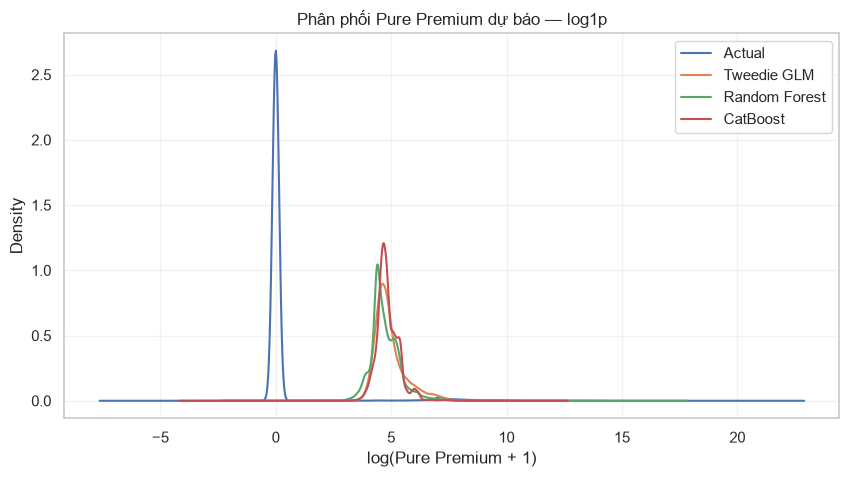

In [31]:
def evaluate_pricing(y_true, pred, exposure, power):
    return {
        "Tweedie Deviance": mean_tweedie_deviance(y_true, pred, power=power, sample_weight=exposure),
        "MAE": mean_absolute_error(y_true, pred, sample_weight=exposure),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred, sample_weight=exposure)),
    }

pricing_results = pd.DataFrame([
    {"Model": "Tweedie GLM", **evaluate_pricing(y_test_tweedie, pred_tweedie_test, w_test, best_p)},
    {"Model": "Random Forest", **evaluate_pricing(y_test_tweedie, pred_rf_test, w_test, best_p)},
    {"Model": "CatBoost Tweedie", **evaluate_pricing(y_test_tweedie, pred_cat_test, w_test, best_p)},
])

print(pricing_results.round(4).to_string(index=False))

plt.figure(figsize=(10, 5))
plot_df = pd.DataFrame({
    "Actual": y_test_tweedie.to_numpy(),
    "Tweedie GLM": pred_tweedie_test,
    "Random Forest": pred_rf_test,
    "CatBoost": pred_cat_test
})
np.log1p(plot_df).plot(kind="kde", figsize=(10, 5))
plt.title("Phân phối Pure Premium dự báo — log1p")
plt.xlabel("log(Pure Premium + 1)")
plt.ylabel("Density")
plt.grid(alpha=0.25)
plt.show()

## 14. Định giá và Loss Ratio

Phí flat benchmark được ước lượng **chỉ từ Train+Validation**, sau đó áp vào Test. Nhờ vậy Loss Ratio của benchmark trên Test không còn mặc định bằng 100%.

Công thức pricing:

`Expected claim cost = Predicted Pure Premium × Exposure`

`Charged premium = Expected claim cost / (1 - expense_margin)`

In [32]:
# Base rate chỉ học từ Train + Validation.
base_pure_premium_rate = (
    train_valid_df["ClaimAmount"].sum() /
    train_valid_df["Exposure"].sum()
)

expense_margin = 0.20

pricing_test = test_df[["IDpol", "Exposure", "ClaimAmount", "ClaimNb"]].copy()
pricing_test["Predicted_PurePremium_Tweedie"] = pred_tweedie_test
pricing_test["Predicted_PurePremium_RF"] = pred_rf_test
pricing_test["Predicted_PurePremium_CatBoost"] = pred_cat_test

pricing_test["Flat_PurePremium"] = base_pure_premium_rate
pricing_test["Flat_Premium"] = pricing_test["Flat_PurePremium"] * pricing_test["Exposure"]

# Chọn CatBoost làm model pricing để minh họa; có thể đổi sang model khác.
pricing_test["ML_Expected_ClaimCost"] = (
    pricing_test["Predicted_PurePremium_CatBoost"] * pricing_test["Exposure"]
)
pricing_test["ML_Premium"] = (
    pricing_test["ML_Expected_ClaimCost"] / (1 - expense_margin)
)

actual_claims = pricing_test["ClaimAmount"].sum()
flat_revenue = pricing_test["Flat_Premium"].sum()
ml_revenue = pricing_test["ML_Premium"].sum()

loss_ratio_flat = actual_claims / flat_revenue
loss_ratio_ml = actual_claims / ml_revenue

print(f"Base pure premium rate từ Train+Validation: {base_pure_premium_rate:.4f}")
print(f"Actual claims trên Test: {actual_claims:,.2f} EUR")
print(f"Flat premium revenue trên Test: {flat_revenue:,.2f} EUR")
print(f"ML premium revenue trên Test: {ml_revenue:,.2f} EUR")
print(f"Loss Ratio — Flat pricing: {loss_ratio_flat:.2%}")
print(f"Loss Ratio — ML pricing: {loss_ratio_ml:.2%}")

summary_pricing = pd.DataFrame({
    "Scenario": ["Flat Pricing", "ML Risk Pricing"],
    "Revenue": [flat_revenue, ml_revenue],
    "Actual Claims": [actual_claims, actual_claims],
    "Loss Ratio": [loss_ratio_flat, loss_ratio_ml]
})
print(summary_pricing.round(4).to_string(index=False))

Base pure premium rate từ Train+Validation: 168.6148
Actual claims trên Test: 8,525,608.84 EUR
Flat premium revenue trên Test: 9,064,713.53 EUR
ML premium revenue trên Test: 8,947,776.69 EUR
Loss Ratio — Flat pricing: 94.05%
Loss Ratio — ML pricing: 95.28%
       Scenario      Revenue  Actual Claims  Loss Ratio
   Flat Pricing 9064713.5304   8525608.8400      0.9405
ML Risk Pricing 8947776.6851   8525608.8400      0.9528


## 15. SHAP — giải thích CatBoost Risk Model

SHAP dùng CatBoost native categorical nên feature importance giữ được tên biến nghiệp vụ như `Area`, `VehBrand`, `BonusMalus`, `DrivAge` thay vì hàng loạt cột One-Hot.

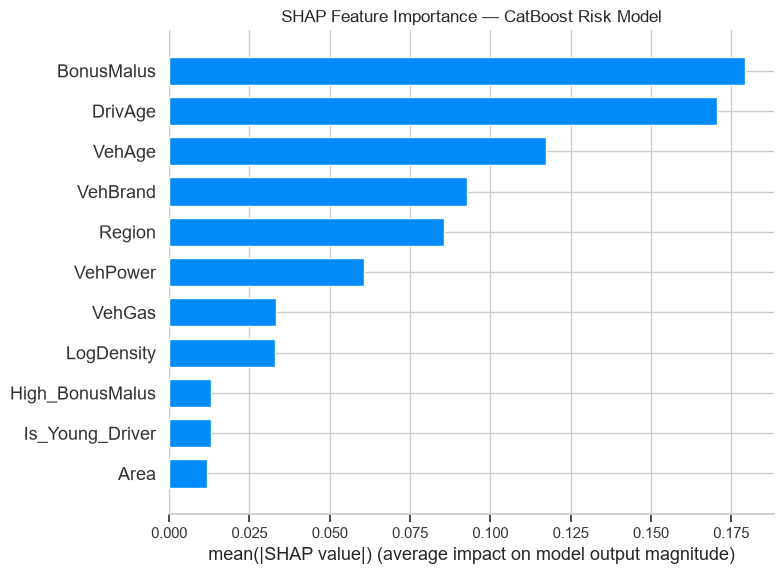

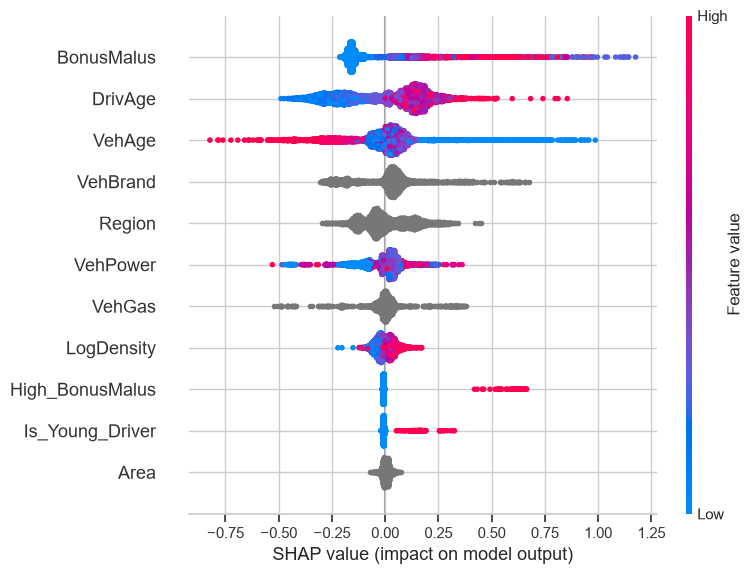

In [33]:
# Lấy base CatBoost classifier đã được fit ở bên trong CalibratedClassifierCV để giải thích.
# CalibratedClassifierCV lưu các estimator đã fit trong calibrated_classifiers_.
cat_explain_model = cat_risk_model

shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(cat_explain_model)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title("SHAP Feature Importance — CatBoost Risk Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_cols,
    show=False
)
plt.tight_layout()
plt.show()

## 16. Kiểm tra sensitivity của claim cap (không dùng làm kết quả chính)

Nếu muốn chứng minh tail claim ảnh hưởng đến pricing, ngưỡng 99% được tính **chỉ trên Train+Validation** và sau đó so sánh trên Test. Kết quả này là sensitivity analysis, không thay thế target `ClaimAmount` nguyên bản.

In [34]:
claim_cap_tv = train_valid_df.loc[train_valid_df["ClaimAmount"] > 0, "ClaimAmount"].quantile(0.99)

train_valid_cap = train_valid_df["ClaimAmount"].clip(upper=claim_cap_tv)
test_claim_cap = test_df["ClaimAmount"].clip(upper=claim_cap_tv)

print(f"99th percentile ClaimAmount tính từ Train+Validation: {claim_cap_tv:,.2f}")
print(f"Tổng claim Test nguyên bản: {test_df['ClaimAmount'].sum():,.2f}")
print(f"Tổng claim Test sau cap: {test_claim_cap.sum():,.2f}")
print("=> Target chính của notebook vẫn là ClaimAmount nguyên bản; cap chỉ dùng cho sensitivity.")

99th percentile ClaimAmount tính từ Train+Validation: 17,948.00
Tổng claim Test nguyên bản: 8,525,608.84
Tổng claim Test sau cap: 6,453,626.69
=> Target chính của notebook vẫn là ClaimAmount nguyên bản; cap chỉ dùng cho sensitivity.


# 17. Tóm tắt kết quả cuối cùng

Notebook này ưu tiên hai mục tiêu khác nhau:

- **Risk:** CatBoost calibrated probability, đánh giá bằng ROC-AUC, PR-AUC, Brier, Gini và Risk Decile.
- **Pricing:** Tweedie GLM, Random Forest và CatBoost Tweedie, đánh giá bằng Tweedie Deviance/MAE/RMSE và so sánh Loss Ratio với flat pricing.

Tập Test được giữ kín cho tới bước đánh giá cuối cùng.

In [35]:
print("=" * 100)
print("KẾT QUẢ CUỐI — RISK MODEL")
print("=" * 100)
print(risk_results.round(4).to_string(index=False))

print("\n" + "=" * 100)
print("KẾT QUẢ CUỐI — PRICING MODEL")
print("=" * 100)
print(pricing_results.round(4).to_string(index=False))

best_risk = risk_results.loc[risk_results["ROC-AUC"].idxmax()]
best_pricing = pricing_results.loc[pricing_results["Tweedie Deviance"].idxmin()]

print("\nBest Risk model theo ROC-AUC:", best_risk["Model"])
print("Best Pricing model theo Tweedie Deviance:", best_pricing["Model"])
print("Để đưa ra mức phí cuối cùng trong thực tế, cần thêm expense loading, profit/risk margin, quy định pháp lý và kiểm định fairness/segmentation trước khi triển khai.")

KẾT QUẢ CUỐI — RISK MODEL
              Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC  Brier   Gini
      Random Forest     0.4952    0.7177     0.0864  0.4825 0.1466   0.6539  0.1055 0.2264 0.3078
CatBoost Calibrated     0.0454    0.6575     0.0811  0.5633 0.1418   0.6601  0.1179 0.0466 0.3202

KẾT QUẢ CUỐI — PRICING MODEL
           Model  Tweedie Deviance      MAE      RMSE
     Tweedie GLM           31.9545 303.8368 6593.9013
   Random Forest           32.0979 311.5983 6831.5564
CatBoost Tweedie           31.9372 275.1142 6592.3077

Best Risk model theo ROC-AUC: CatBoost Calibrated
Best Pricing model theo Tweedie Deviance: CatBoost Tweedie
Để đưa ra mức phí cuối cùng trong thực tế, cần thêm expense loading, profit/risk margin, quy định pháp lý và kiểm định fairness/segmentation trước khi triển khai.


SAVE MODELS

In [36]:
import os
import joblib

os.makedirs("/content/models", exist_ok=True)

# Risk model
cat_risk_model.save_model(
    "/content/models/catboost_risk.cbm"
)

# Pricing model
joblib.dump(
    pricing_tweedie,
    "/content/models/tweedie_pricing.pkl"
)

# Calibration
joblib.dump(
    prob_calibrator,
    "/content/models/probability_calibrator.pkl"
)

# Threshold
joblib.dump(
    cat_threshold,
    "/content/models/risk_threshold.pkl"
)

# Preprocessor
joblib.dump(
    preprocessor,
    "/content/models/preprocessor.pkl"
)

# Config
model_config = {
    "num_features": num_features,
    "cat_features": cat_features,
    "feature_cols": feature_cols,
    "expense_margin": expense_margin,
    "random_state": RANDOM_STATE
}

joblib.dump(
    model_config,
    "/content/models/model_config.pkl"
)

print("Đã lưu model thành công!")

Đã lưu model thành công!


In [ ]:
import sklearn
import joblib
import numpy
import pandas

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)

sklearn: 1.6.1
joblib: 1.5.3
numpy: 2.1.3
pandas: 2.2.3
